In [121]:
import math
import numpy as np
import matplotlib.pyplot as plt

In [122]:
TS  = 100
TD = -100

100 2499


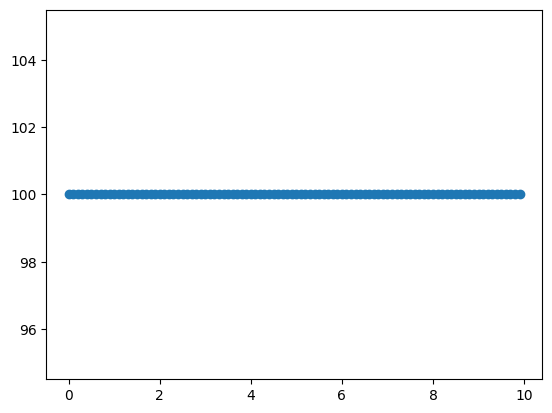

In [123]:
L = 10      # Lunghezza Sbarra
T = 10     # secondi

RIS = 100   # risoluzione spaziale
D = 1      # dipende dal materiale (HO USATO IL RAME)

DX = L / RIS
DT = 0.4 * DX**2 / D   # Condizioni di von neuman   

N = int(L / DX)
T = int(T / DT)

print(N,T)

C = np.zeros((N,T))
x = np.arange(N) * DX

mu    = L * 0.5     # sposta il picco: 0.3 = sinistra, 0.7 = destra  
sigma = L * 0.05    # picco stretto
T_max = 100         # temperatura massima del picco in gradi

C[0:, 0] = TS
C[N:, 0] = TD
assert T > 0, "Tempo fisico troppo corto rispetto a DT!"
x = np.arange(C.shape[0]) * DX
plt.scatter(x,C[:,0])


In [124]:
nu = DT/(DX**2)
print(nu)
for i in range(T):
    C[1:-1,1:] = C[1:-1, :-1] + nu*(C[2:,:-1] + C[:-2,:-1] - 2*C[1:-1,:-1])
    C[0:, 0] = TS
    C[N:, 0] = TD

# Ricorda che il nu deve rispettare la condizione di von neuman
# (20.21) sul landau


0.4


100 2499


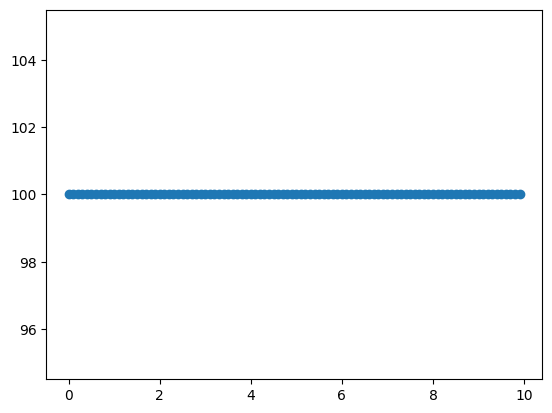

In [125]:
L = 10      # Lunghezza Sbarra
T = 10     # secondi

RIS = 100   # risoluzione spaziale
D = 1      # dipende dal materiale (HO USATO IL RAME)

DX = L / RIS
DT = 0.4 * DX**2 / D   # Condizioni di von neuman   

N = int(L / DX)
T = int(T / DT)

print(N,T)

C1 = np.zeros((N,T))
x = np.arange(N) * DX

mu    = L * 0.5     # sposta il picco: 0.3 = sinistra, 0.7 = destra  
sigma = L * 0.05    # picco stretto
T_max = 100         # temperatura massima del picco in gradi

C1[0:, 0] = TS
C1[N:, 0] = TD
assert T > 0, "Tempo fisico troppo corto rispetto a DT!"
x = np.arange(C1.shape[0]) * DX
plt.scatter(x,C1[:,0])


In [126]:
nu = DT/(DX**2)
h = 0.0005
print(nu)
for i in range(T):
    C1[1:-1,1:] = C1[1:-1, :-1] + nu*(C1[2:,:-1] + C1[:-2,:-1] - 2*C1[1:-1,:-1]) - h*C1[1:-1, :-1]
    C1[0:, 0] = TS
    C1[N:, 0] = TD

# Ricorda che il nu deve rispettare la condizione di von neuman
# (20.21) sul landau


0.4


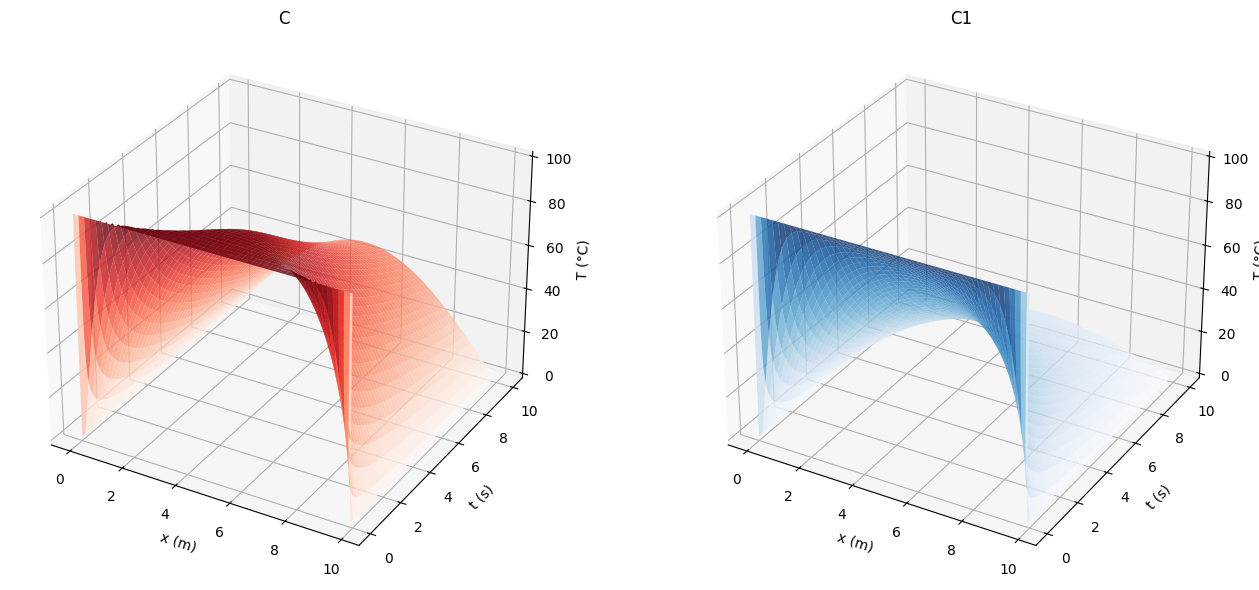

In [127]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(C.shape[0]) * DX
t = np.arange(C.shape[1]) * DT

X, T_grid = np.meshgrid(x, t)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot_surface(X, T_grid, C.T, cmap='Reds', alpha=0.8)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('t (s)')
ax1.set_zlabel('T (°C)')
ax1.set_title('C')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_surface(X, T_grid, C1.T, cmap='Blues', alpha=0.8)
ax2.set_xlabel('x (m)')
ax2.set_ylabel('t (s)')
ax2.set_zlabel('T (°C)')
ax2.set_title('C1')

plt.tight_layout()
plt.show()
